# Parameters

In [ ]:
parameters = {
"beta" : 0.0001,  # loss of public and private because of competition
"gamma" : 0.0001,  # cost spent by private population
"alpha" : 0.0002,  # benefit from cooperator to defector
"eta" : 0.0001,  # cost spent by public population   
"r_c" : 0.5,  # growth rate (benefit) of public
"r_p" : 0.2,  # growth rate (benefit) of private
"nu" : 0.0001,  # transportation cost of defector
}

# Changing growth rate rc and rp

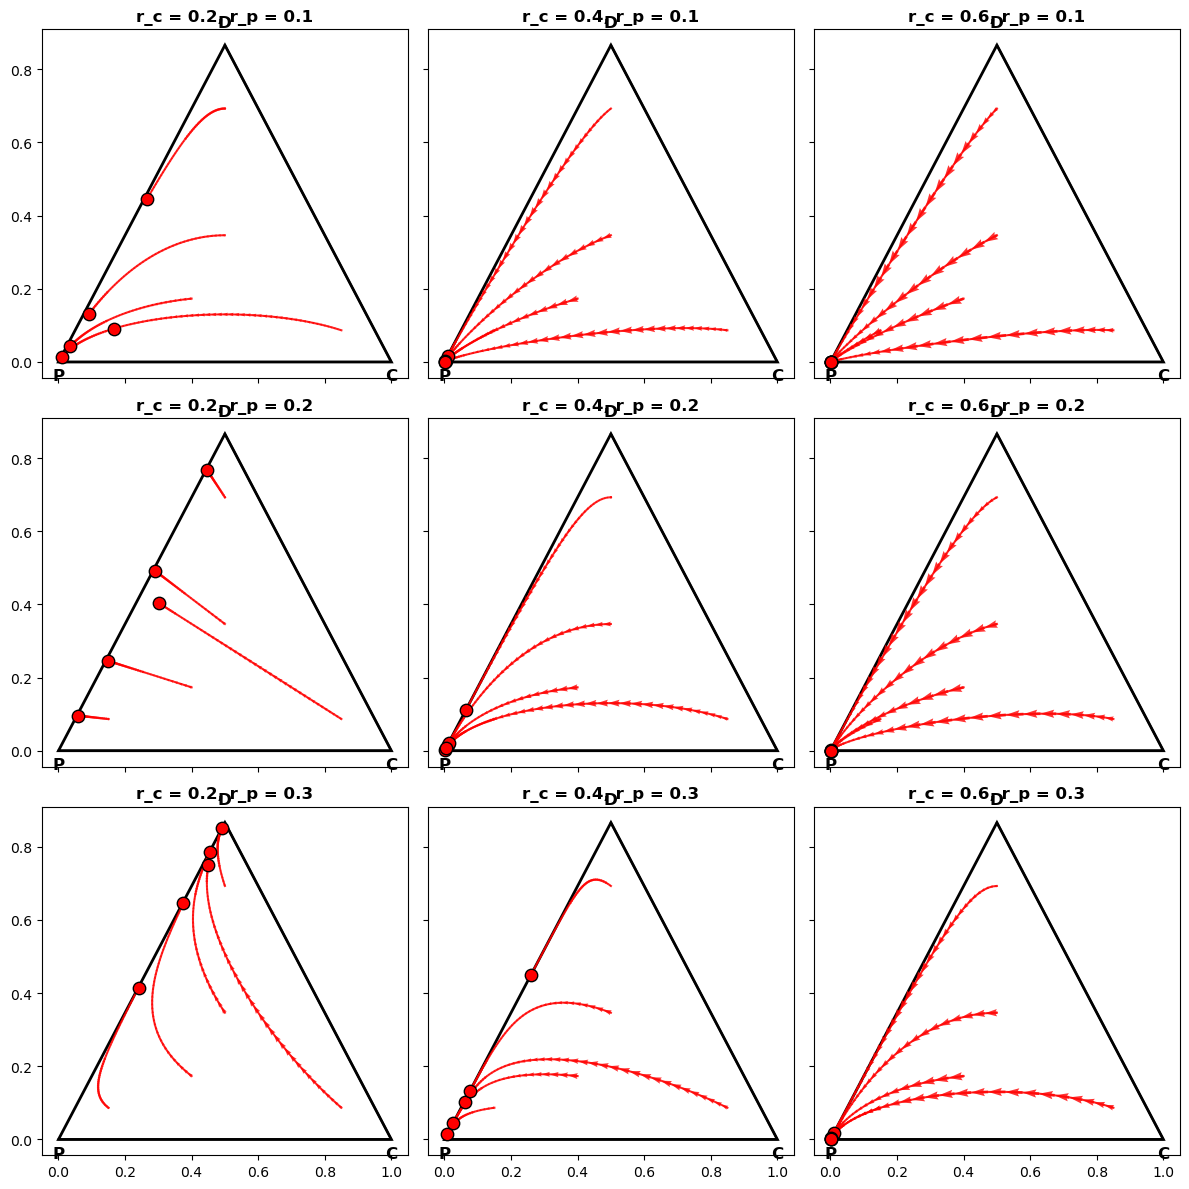

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.spatial import ConvexHull
from src.parameters import parameters  # Import parameters dictionary

# Define variations for r_c and r_p
rc_values = [0.2, 0.4, 0.6]  # Public growth rate
rp_values = [0.1, 0.2, 0.3]  # Private growth rate

# Convert barycentric to Cartesian coordinates
def to_cartesian(x):
    return np.array([
        0.5 * (2 * x[:, 1] + x[:, 2]),  # X coordinate
        np.sqrt(3) / 2 * x[:, 2]  # Y coordinate
    ]).T

# Define the replicator equations
def replicator_equations(x, t, params):
    C, D, P = x
    fitness_C = params["r_c"] - params["alpha"] * D - params["beta"] * P
    fitness_D = params["alpha"] * C - params["nu"] * D
    fitness_P = params["r_p"] - params["beta"] * C - params["gamma"] * P
    avg_fitness = C * fitness_C + D * fitness_D + P * fitness_P
    return [C * (fitness_C - avg_fitness), D * (fitness_D - avg_fitness), P * (fitness_P - avg_fitness)]

# Function to compute Jacobian matrix
def jacobian_matrix(C, D, P, params):
    r_c, alpha, beta, nu, r_p, gamma = params["r_c"], params["alpha"], params["beta"], params["nu"], params["r_p"], params["gamma"]
    
    fitness_C = r_c - alpha * D - beta * P
    fitness_D = alpha * C - nu * D
    fitness_P = r_p - beta * C - gamma * P
    avg_fitness = C * fitness_C + D * fitness_D + P * fitness_P
    
    J = np.array([
        [C * (fitness_C - avg_fitness) + C * (r_c - alpha * D - beta * P), -C * alpha, -C * beta],
        [D * alpha, D * (fitness_D - avg_fitness) + D * (alpha * C - nu * D), 0],
        [-P * beta, 0, P * (fitness_P - avg_fitness) + P * (r_p - beta * C - gamma * P)]
    ])
    return J

# Function to check stability using Jacobian eigenvalues
def is_stable(equilibrium, params):
    J = jacobian_matrix(*equilibrium, params)
    eigenvalues = np.linalg.eigvals(J)
    return np.all(np.real(eigenvalues) < 0)  # Stable if all eigenvalues have negative real parts

# initial population distributions
initial_conditions = [
    [0.8, 0.1, 0.1],  # Mostly cooperators
    [0.1, 0.8, 0.1],  # Mostly defectors
    [0.1, 0.1, 0.8],  # Mostly private population
    [0.3, 0.3, 0.4],  # Mixed
    [0.5, 0.3, 0.2],  # Balanced
]

# Create figure
fig, axes = plt.subplots(len(rp_values), len(rc_values), figsize=(12, 12), sharex=True, sharey=True)

for i, r_p in enumerate(rp_values):
    for j, r_c in enumerate(rc_values):
        parameters.update({"r_c": r_c, "r_p": r_p})

        equilibrium_states = []
        trajectories = []
        t = np.linspace(0, 20, 50)

        # Simulate replicator dynamics for each initial condition
        for x0 in initial_conditions:
            sol = odeint(replicator_equations, x0, t, args=(parameters,))
            trajectories.append(sol)
            equilibrium_states.append(sol[-1])

        equilibrium_states = np.array(equilibrium_states)
        equilibrium_cartesian = to_cartesian(equilibrium_states)

        # Identify stable and unstable equilibria
        stable_indices = np.array([k for k, eq in enumerate(equilibrium_states) if is_stable(eq, parameters)], dtype=int)
        unstable_indices = np.array([k for k, eq in enumerate(equilibrium_states) if not is_stable(eq, parameters)], dtype=int)

        # Plot the simplex
        ax = axes[i, j]
        triangle_vertices = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
        ax.plot(triangle_vertices[:, 0], triangle_vertices[:, 1], 'k-', linewidth=1.5)
        ax.fill(triangle_vertices[:, 0], triangle_vertices[:, 1], edgecolor='black', linewidth=2, fill=False)

        # Scatter stable and unstable equilibrium points
        if len(stable_indices) > 0:
            ax.scatter(equilibrium_cartesian[stable_indices, 0], equilibrium_cartesian[stable_indices, 1],
                       color='green', s=80, edgecolors='black', marker='o', label='Stable Equilibria', zorder=3)

        if len(unstable_indices) > 0:
            ax.scatter(equilibrium_cartesian[unstable_indices, 0], equilibrium_cartesian[unstable_indices, 1],
                       color='red', s=80, edgecolors='black', marker='o', label='Unstable Equilibria', zorder=3)

        # Overlay selected trajectories with arrows
        for sol in trajectories:
            cart_sol = to_cartesian(sol)
            ax.plot(cart_sol[:, 0], cart_sol[:, 1], color='red', alpha=0.8, linewidth=1.5)
            ax.quiver(cart_sol[:-1, 0], cart_sol[:-1, 1],
                      cart_sol[1:, 0] - cart_sol[:-1, 0],
                      cart_sol[1:, 1] - cart_sol[:-1, 1],
                      scale_units='xy', angles='xy', scale=1, alpha=0.8, color='red')

        # Label the strategies at the vertices
        ax.text(0, -0.05, 'P', fontsize=12, fontweight='bold', ha='center', color='black')
        ax.text(1, -0.05, 'C', fontsize=12, fontweight='bold', ha='center', color='black')
        ax.text(0.5, np.sqrt(3)/2 + 0.05, 'D', fontsize=12, fontweight='bold', ha='center', color='black')

        ax.set_title(f"r_c = {r_c}, r_p = {r_p}", fontsize=12, fontweight="bold")

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


# Alpha and Beta value is changing  with random initial value

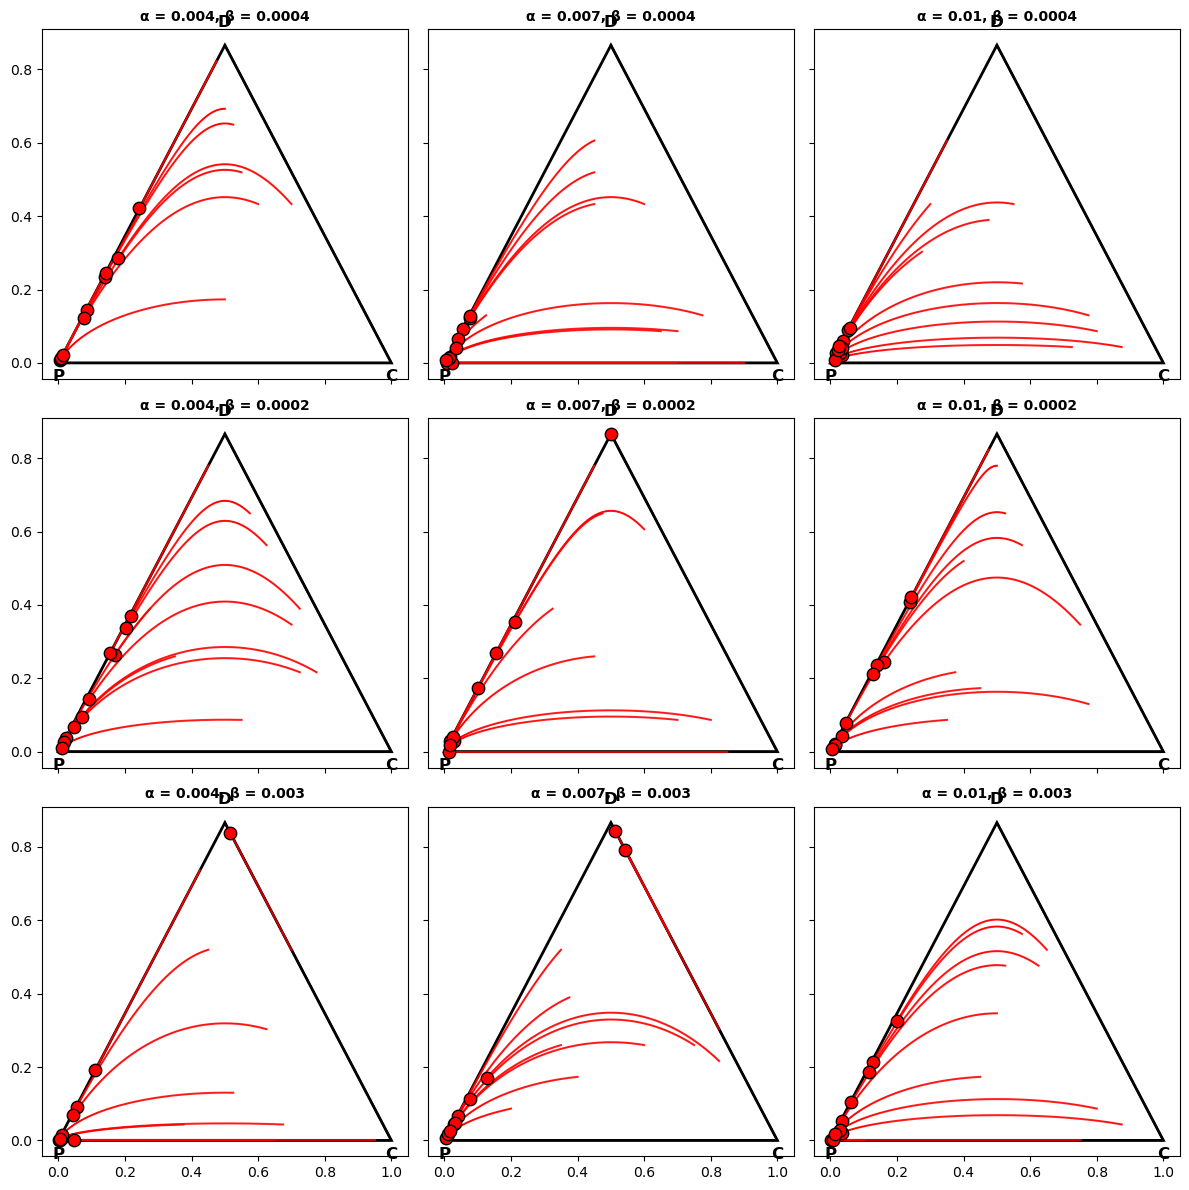

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.spatial import ConvexHull
from src.model import deriv  # Import the model function
from src.parameters import parameters  # Import parameters dictionary

# Define parameter variations
alpha_values = [0.004, 0.007, 0.01]  #  (public-to-defector benefit)
beta_values = [0.0004, 0.0002, 0.003]  # (competition between public and private)

# Convert barycentric to Cartesian coordinates
def to_cartesian(x):
    return np.array([
        0.5 * (2 * x[:, 1] + x[:, 2]),  # X coordinate
        np.sqrt(3) / 2 * x[:, 2]  # Y coordinate
    ]).T

# Generate grid points for the simplex
num_points = 20
barycentric_grid = np.array([[a/num_points, b/num_points, (num_points-a-b)/num_points]
                            for a in range(num_points + 1)
                            for b in range(num_points + 1 - a)])

# Define the replicator equations
def replicator_equations(x, t, params):
    C, D, P = x
    fitness_C = params["r_c"] - params["alpha"] * D - params["beta"] * P
    fitness_D = params["alpha"] * C - params["nu"] * D
    fitness_P = params["r_p"] - params["beta"] * C - params["gamma"] * P
    avg_fitness = C * fitness_C + D * fitness_D + P * fitness_P
    return [C * (fitness_C - avg_fitness), D * (fitness_D - avg_fitness), P * (fitness_P - avg_fitness)]

# Function to compute Jacobian matrix
def jacobian_matrix(C, D, P, params):
    r_c, alpha, beta, nu, r_p, gamma = params["r_c"], params["alpha"], params["beta"], params["nu"], params["r_p"], params["gamma"]
    
    fitness_C = r_c - alpha * D - beta * P
    fitness_D = alpha * C - nu * D
    fitness_P = r_p - beta * C - gamma * P
    avg_fitness = C * fitness_C + D * fitness_D + P * fitness_P
    
    J = np.array([
        [C * (fitness_C - avg_fitness) + C * (r_c - alpha * D - beta * P), -C * alpha, -C * beta],
        [D * alpha, D * (fitness_D - avg_fitness) + D * (alpha * C - nu * D), 0],
        [-P * beta, 0, P * (fitness_P - avg_fitness) + P * (r_p - beta * C - gamma * P)]
    ])
    return J

# Function to check stability using Jacobian eigenvalues
def is_stable(equilibrium, params):
    J = jacobian_matrix(*equilibrium, params)
    eigenvalues = np.linalg.eigvals(J)
    return np.all(np.real(eigenvalues) < 0)  # Stable if all eigenvalues have negative real parts

# Function to check stability using perturbation tests
def is_numerically_stable(equilibrium, params, dt=0.1, T=30):
    perturbed = equilibrium + np.random.uniform(-0.01, 0.01, size=3)  # Small perturbation
    perturbed = np.clip(perturbed, 0, 1)  
    t = np.linspace(0, T, int(T/dt))
    
    sol = odeint(replicator_equations, perturbed, t, args=(params,))
    final_state = sol[-1]
    
    return np.linalg.norm(final_state - equilibrium) < 0.01  # Check if returns close to equilibrium

# Create figure
fig, axes = plt.subplots(len(beta_values), len(alpha_values), figsize=(12, 12), sharex=True, sharey=True)

for i, beta in enumerate(beta_values):
    for j, alpha in enumerate(alpha_values):
        parameters.update({"r_c": r_c, "r_p": r_p, "alpha": alpha, "beta": beta})
        
        # Simulate replicator dynamics for selected initial conditions
        selected_indices = np.random.choice(len(barycentric_grid), 10, replace=False) # initial conditions
        equilibrium_states = []
        trajectories = []
        t = np.linspace(0, 10, 500)

        for idx in selected_indices:
            x0 = barycentric_grid[idx]
            sol = odeint(replicator_equations, x0, t, args=(parameters,))
            trajectories.append(sol)
            equilibrium_states.append(sol[-1])

        equilibrium_states = np.array(equilibrium_states)
        equilibrium_cartesian = to_cartesian(equilibrium_states)

        # Identify stable and unstable equilibria
        stable_indices = np.array([i for i, eq in enumerate(equilibrium_states) if is_stable(eq, parameters)], dtype=int)
        unstable_indices = np.array([i for i, eq in enumerate(equilibrium_states) if not is_stable(eq, parameters)], dtype=int)

        # Plot the simplex
        ax = axes[i, j]
        triangle_vertices = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
        ax.plot(triangle_vertices[:, 0], triangle_vertices[:, 1], 'k-', linewidth=1.5)
        ax.fill(triangle_vertices[:, 0], triangle_vertices[:, 1], edgecolor='black', linewidth=2, fill=False)

        # Scatter stable and unstable equilibrium points
        if len(stable_indices) > 0:
            ax.scatter(equilibrium_cartesian[stable_indices, 0], equilibrium_cartesian[stable_indices, 1],
                       color='green', s=80, edgecolors='black', marker='o', label='Stable Equilibria', zorder=3)

        if len(unstable_indices) > 0:
            ax.scatter(equilibrium_cartesian[unstable_indices, 0], equilibrium_cartesian[unstable_indices, 1],
                       color='red', s=80, edgecolors='black', marker='o', label='Unstable Equilibria', zorder=3)

        # Overlay selected trajectories with arrows
        for sol in trajectories:
            cart_sol = to_cartesian(sol)
            ax.plot(cart_sol[:, 0], cart_sol[:, 1], color='red', alpha=0.8, linewidth=1.5)
            ax.quiver(cart_sol[:-1, 0], cart_sol[:-1, 1],
                      cart_sol[1:, 0] - cart_sol[:-1, 0],
                      cart_sol[1:, 1] - cart_sol[:-1, 1],
                      scale_units='xy', angles='xy', scale=1, alpha=0.8, color='red')

        # Label the strategies at the vertices
        ax.text(0, -0.05, 'P', fontsize=12, fontweight='bold', ha='center', color='black')
        ax.text(1, -0.05, 'C', fontsize=12, fontweight='bold', ha='center', color='black')
        ax.text(0.5, np.sqrt(3)/2 + 0.05, 'D', fontsize=12, fontweight='bold', ha='center', color='black')

        ax.set_title(f"α = {alpha}, β = {beta}", fontsize=10, fontweight="bold")

# Adjust layout and show the figure
plt.tight_layout()
plt.show()
